<h1 style="text-align: center;">Module 1. Structured data processing using neural networks
</h1>
<h2 style="text-align: center;">Topic 2. Logistic regression. Artificial neuron</h2>

## Dataset overview

The dataset used in this project is available on Kaggle:

[Spaceship Titanic dataset](https://www.kaggle.com/competitions/spaceship-titanic/overview)

**Data Field Description:**
* `PassengerId` - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
* `HomePlanet` - The planet the passenger departed from, typically their planet of permanent residence.
* `CryoSleep` - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
* `Cabin` - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
* `Destination` - The planet the passenger will be debarking to.
* `Age` - The age of the passenger.
* `VIP` - Whether the passenger has paid for special VIP service during the voyage.
* `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck` - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
* `Name` - The first and last names of the passenger.
* `Transported` - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


## Exploratory Data Analysis

In [5]:
df = pd.read_csv(
    "../data/Module_1_Lecture_2_Class_Spaceship_Titanic.csv"
)

df = df.set_index("PassengerId")

In [ ]:
# Dataset preview
df.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
# Number of records and columns
df.shape

(8693, 13)

In [ ]:
# Basic dataset info 
df.info()

<class 'pandas.DataFrame'>
Index: 8693 entries, 0001_01 to 9280_02
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   str    
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   str    
 3   Destination   8511 non-null   str    
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Name          8493 non-null   str    
 12  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(4)
memory usage: 891.4+ KB


In [51]:
TARGET = "Transported"

FEATURES = [
    column for column in df.columns
    if column != TARGET
]

text_features = ["Cabin", "Name"]

cat_features = [
    column for column in FEATURES
    if df[column].nunique() < 25
    and column not in text_features
]

cont_features = [
    column for column in FEATURES
    if df[column].nunique() >= 25
    and column not in text_features
]

print(f'Number of categorical features: {len(cat_features)}')
print('Categorical features:', cat_features, '\n')
print(f'Number of continuos features: {len(cont_features)}')
print('Continuos features:', cont_features, '\n')
print(f'Number of text features: {len(text_features)}')
print('Text features:', text_features)

Number of categorical features: 17
Categorical features: ['CryoSleep', 'VIP', 'used_RoomService', 'used_FoodCourt', 'used_ShoppingMall', 'used_Spa', 'used_VRDeck', 'CryoSleep_is_missing', 'VIP_is_missing', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'HomePlanet_Unknown', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_Unknown'] 

Number of continuos features: 6
Continuos features: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'] 

Number of text features: 2
Text features: ['Cabin', 'Name']


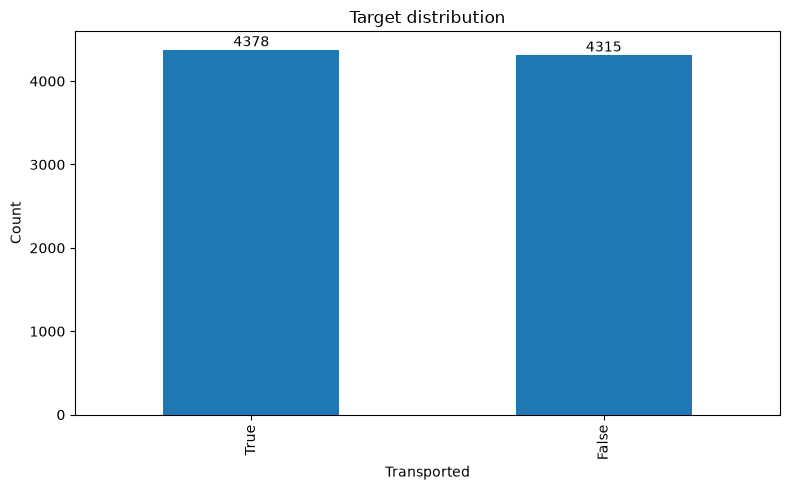

In [10]:
ax = df[TARGET].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_xlabel("Transported")
ax.set_ylabel("Count")
ax.set_title("Target distribution")

plt.tight_layout()
plt.show()

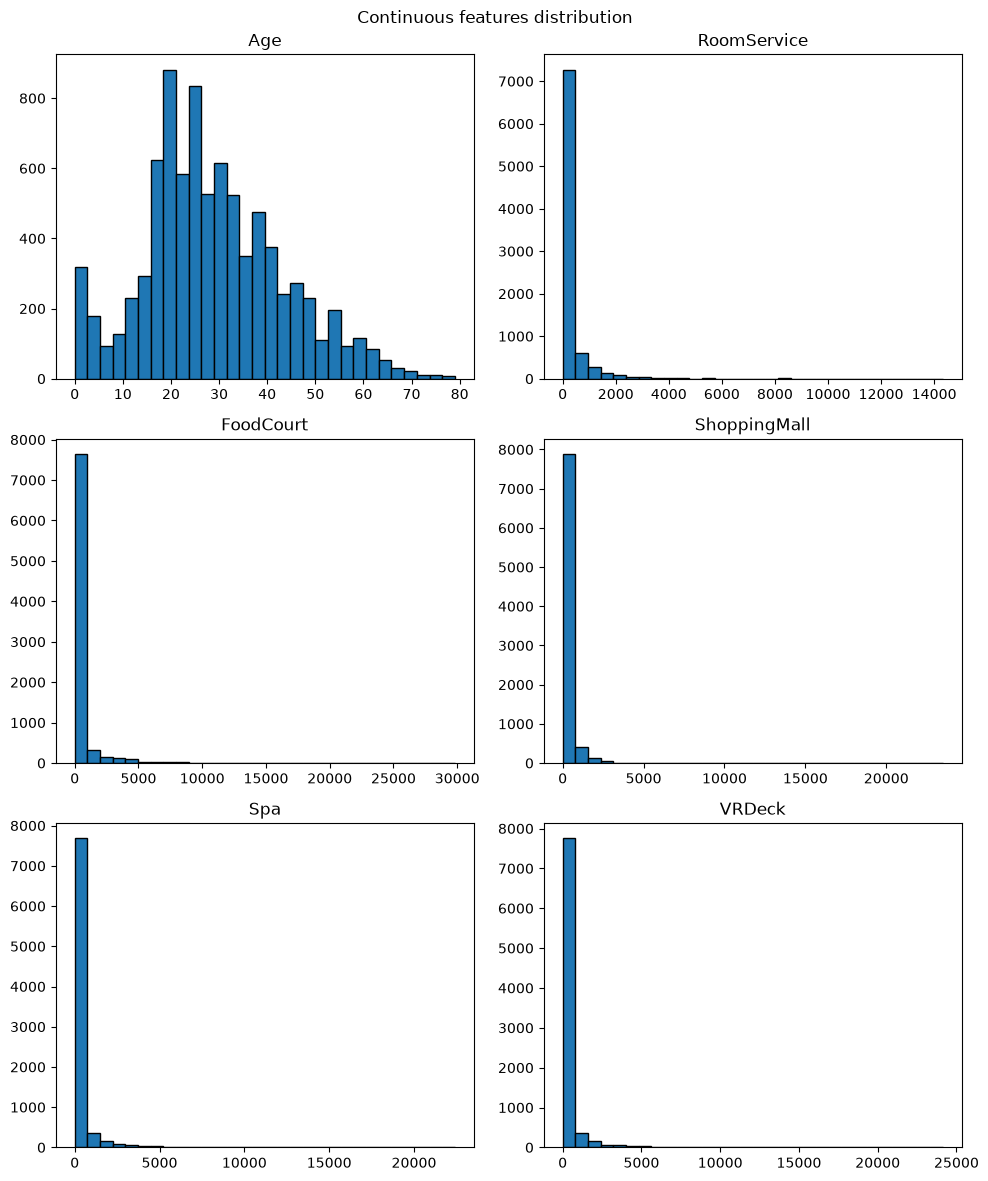

In [11]:
df[cont_features].hist(
    figsize=(10, 12),
    bins=30,
    grid=False,
    edgecolor="black"
)

plt.suptitle("Continuous features distribution")
plt.tight_layout()
plt.show()

In [14]:
services_features = cont_features[1:]

for feature in services_features:
    df[f"used_{feature}"] = (
        df[feature] > 0
    ).astype(int)


In [15]:
corr_df = df[
    cont_features + ["CryoSleep", "VIP", TARGET]
].copy()

corr_df["CryoSleep"] = corr_df["CryoSleep"].astype("boolean")
corr_df["VIP"] = corr_df["VIP"].astype("boolean")

corr_matrix = corr_df.corr(numeric_only=True)

corr_matrix.round(2)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,CryoSleep,VIP,Transported
Age,1.00,0.07,0.13,0.03,0.12,0.10,-0.07,0.09,-0.08
RoomService,0.07,1.00,-0.02,0.05,0.01,-0.02,-0.25,0.06,-0.24
FoodCourt,0.13,-0.02,1.00,-0.01,0.22,0.23,-0.21,0.13,0.05
ShoppingMall,0.03,0.05,-0.01,1.00,0.01,-0.01,-0.21,0.02,0.01
Spa,0.12,0.01,0.22,0.01,1.00,0.15,-0.20,0.06,-0.22
VRDeck,0.10,-0.02,0.23,-0.01,0.15,1.00,-0.20,0.13,-0.21
CryoSleep,-0.07,-0.25,-0.21,-0.21,-0.20,-0.20,1.00,-0.08,0.47
VIP,0.09,0.06,0.13,0.02,0.06,0.13,-0.08,1.00,-0.04
Transported,-0.08,-0.24,0.05,0.01,-0.22,-0.21,0.47,-0.04,1.00


In [16]:
corr_matrix.style.background_gradient(
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,CryoSleep,VIP,Transported
Age,1.000000,0.068723,0.130421,0.033133,0.123970,0.101007,-0.074273,0.092819,-0.075026
RoomService,0.068723,1.000000,-0.015889,0.054480,0.010080,-0.019581,-0.252396,0.058785,-0.244611
FoodCourt,0.130421,-0.015889,1.000000,-0.014228,0.221891,0.227995,-0.211510,0.129799,0.046566
ShoppingMall,0.033133,0.054480,-0.014228,1.000000,0.013879,-0.007322,-0.212514,0.018295,0.010141
Spa,0.123970,0.010080,0.221891,0.013879,1.000000,0.153821,-0.203991,0.061059,-0.221131
VRDeck,0.101007,-0.019581,0.227995,-0.007322,0.153821,1.000000,-0.198857,0.125974,-0.207075
CryoSleep,-0.074273,-0.252396,-0.211510,-0.212514,-0.203991,-0.198857,1.000000,-0.081402,0.468645
VIP,0.092819,0.058785,0.129799,0.018295,0.061059,0.125974,-0.081402,1.000000,-0.037650
Transported,-0.075026,-0.244611,0.046566,0.010141,-0.221131,-0.207075,0.468645,-0.037650,1.000000


## Preprocessing

In [ ]:
# 1. Numeric missing values
imputer_cols = [
    "Age",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
    "RoomService"
]

imputer = SimpleImputer(strategy="median")

df[imputer_cols] = imputer.fit_transform(df[imputer_cols])

In [18]:
df[imputer_cols].isna().sum()

Age             0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
RoomService     0
dtype: int64

In [ ]:
# 2. Categorical missing values
df["HomePlanet"] = df["HomePlanet"].fillna("Unknown")
df["Destination"] = df["Destination"].fillna("Unknown")

In [ ]:
# 3. Missing-value indicators
df["CryoSleep_is_missing"] = df["CryoSleep"].isna().astype(int)
df["VIP_is_missing"] = df["VIP"].isna().astype(int)

In [ ]:
# 4. Binary columns
display(df["CryoSleep"].value_counts())
display(df["VIP"].value_counts())

CryoSleep
False    5439
True     3037
Name: count, dtype: int64

VIP
False    8291
True      199
Name: count, dtype: int64

In [ ]:
# 4. Binary columns
df["CryoSleep"] = df["CryoSleep"].fillna(False).astype(int)
df["VIP"] = df["VIP"].fillna(False).astype(int)

In [ ]:
# 5. One-hot encoding
dummies = pd.get_dummies(
    df[["HomePlanet", "Destination"]],
    dtype=int
)

dummies.head()

,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_Unknown,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Destination_Unknown
PassengerId,,,,,,,,
0001_01,0,1,0,0,0,0,1,0
0002_01,1,0,0,0,0,0,1,0
0003_01,0,1,0,0,0,0,1,0
0003_02,0,1,0,0,0,0,1,0
0004_01,1,0,0,0,0,0,1,0


In [24]:
df = pd.concat([df, dummies], axis=1)

df = df.drop(
    columns=["HomePlanet", "Destination"]
)

In [ ]:
# 6. Target
df[TARGET] = df[TARGET].astype(int)

In [ ]:
# 7. Remove unprocessed text
df = df.drop(
    columns=["Name", "Cabin"]
)

df.info()

<class 'pandas.DataFrame'>
Index: 8693 entries, 0001_01 to 9280_02
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CryoSleep                  8693 non-null   int64  
 1   Age                        8693 non-null   float64
 2   VIP                        8693 non-null   int64  
 3   RoomService                8693 non-null   float64
 4   FoodCourt                  8693 non-null   float64
 5   ShoppingMall               8693 non-null   float64
 6   Spa                        8693 non-null   float64
 7   VRDeck                     8693 non-null   float64
 8   Transported                8693 non-null   int64  
 9   used_RoomService           8693 non-null   int64  
 10  used_FoodCourt             8693 non-null   int64  
 11  used_ShoppingMall          8693 non-null   int64  
 12  used_Spa                   8693 non-null   int64  
 13  used_VRDeck                8693 non-null   int64  
 14 

In [ ]:
# 8. Split into X and y
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [ ]:
# 9. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

In [31]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain target:")
print(y_train.value_counts(normalize=True))

print("\nTest target:")
print(y_test.value_counts(normalize=True))

Train: (5824, 23)
Test: (2869, 23)

Train target:
Transported
1    0.503606
0    0.496394
Name: proportion, dtype: float64

Test target:
Transported
1    0.50366
0    0.49634
Name: proportion, dtype: float64


In [ ]:
# 10. Convert to NumPy and transpose
x_train = X_train.T
x_test = X_test.T
y_train = np.expand_dims(y_train.T, 0)
y_test = np.expand_dims(y_test.T, 0)

In [33]:
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (23, 5824)
x_test: (23, 2869)
y_train: (1, 5824)
y_test: (1, 2869)


## Initializing parameters

In [ ]:
# 1. Initialize weights and bias
def initialize_weights_and_bias(dimension):
    # dimension - number of input features
    w = np.full((dimension,1),0.01)
    b = 0.0
    return w, b

## Forward Propagation

In [ ]:
# 2. Sigmoid activation function
def sigmoid(z):
    y_head = 1/(1+np.exp(-z))
    return y_head

In [ ]:
# 3. Forward propagation
def forward_propagation(w,b,x_train,y_train):
    # Linear calculation
    z = np.dot(w.T,x_train) + b

     # Convert z to probabilities between 0 and 1
    y_head = sigmoid(z) # probabilistic 0-1

     # Binary cross-entropy loss for every training example
    loss = -1*y_train*np.log(y_head)-(1-y_train)*np.log(1-y_head)

     # Average loss for the whole training dataset
    cost = (np.sum(loss))/x_train.shape[1]      # x_train.shape[1] is for scaling
    return cost

## Gradient Descent

In [ ]:
# 4. Forward and backward propagation
# In backward propagation we will use y_head that found in forward propagation
# Therefore instead of writing the backward propagation method,
# let's combine forward propagation and backward propagation
def forward_backward_propagation(w,b,x_train,y_train, eps=1e-5):

    # forward propagation
    z = np.dot(w.T,x_train) + b
    y_head = sigmoid(z)
    loss = -1*y_train*np.log(y_head+eps)-(1-y_train)*np.log(1-y_head+eps)
    cost = (np.sum(loss))/x_train.shape[1]

    # backward propagation
    derivative_weight = (np.dot(x_train,((y_head-y_train).T)))/x_train.shape[1]
    derivative_bias = np.sum(y_head-y_train)/x_train.shape[1]

    gradients = {
        "derivative_weight": derivative_weight,
        "derivative_bias": derivative_bias
    }

    return cost, gradients

In [ ]:
# 5. Updating(learning) parameters
def update(w, b, x_train, y_train, learning_rate,number_of_iteration):
    cost_list = []
    index = []

    # updating(learning) parameters is number_of_iteration times
    for i in range(number_of_iteration):

        # make forward and backward propagation
        # and find cost and gradients
        cost,gradients = forward_backward_propagation(
            w,
            b,
            x_train,
            y_train
        )

        # save cost and iteration number
        cost_list.append(cost)
        index.append(i)

        # lets update
        # update weights and bias
        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]

    # learned parameters
    # we update(learn) parameters weights and bias
    parameters = {
        "weight": w,
        "bias": b
    }
    
    # cost graph 
    plt.plot(index,cost_list)
    plt.xticks(index,rotation='vertical')
    plt.xlabel("Number of Iteration")
    plt.ylabel("Cost")
    plt.show()

    return parameters, gradients, cost_list

In [ ]:
# 6. Prediction function
# convert probabilities into classes
def predict(w,b,x_test):
    # x_test is a input for forward propagation
    z = sigmoid(np.dot(w.T,x_test)+b)
    
    # create array for predicted classes
    Y_prediction = np.zeros((1,x_test.shape[1]))

    # convert probabilities into classes
    # if z is bigger than 0.5, our prediction is sign one
    # if z is smaller than 0.5, our prediction is sign zero
    for i in range(z.shape[1]):
        if z[0,i] <= 0.5:
            Y_prediction[0,i] = 0
        else:
            Y_prediction[0,i] = 1

    return Y_prediction

In [ ]:
# 7. Final logistic regression model
def logistic_regression(
    x_train,
    y_train,
    x_test,
    y_test,
    learning_rate,
    num_iterations
):
    # initialize parameters
    dimension = x_train.shape[0]
    w,b = initialize_weights_and_bias(dimension)
   
    # train the model
    parameters, gradients, cost_list = update(
        w,
        b,
        x_train,
        y_train,
        learning_rate,
        num_iterations
    )
    
    # predictions
    y_prediction_test = predict(
        parameters["weight"],
        parameters["bias"],
        x_test
    )

    y_prediction_train = predict(
        parameters["weight"],
        parameters["bias"],
        x_train
    )

    # train accuracy
    print(
        "train accuracy: {} %".format(
            100 - np.mean(
                np.abs(y_prediction_train - y_train)
            ) * 100
        )
    )

    # test accuracy
    print(
        "test accuracy: {} %".format(
            100 - np.mean(
                np.abs(y_prediction_test - y_test)
            ) * 100
        )
    )

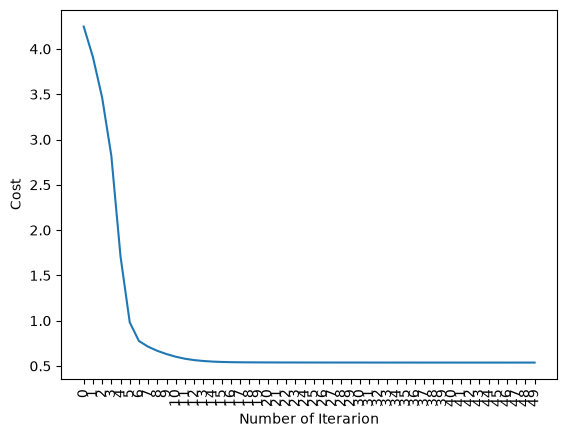

train accuracy: 77.93612637362638 %
test accuracy: 79.36563262460788 %


In [ ]:
# 8. Train and evaluate the model
logistic_regression(
    x_train,
    y_train,
    x_test,
    y_test,
    learning_rate=0.00001,
    num_iterations=50
)